# physprior — what does a physics prior buy you?

A neural network can fit almost any curve. A physicist writes a law with two
constants in it. On **real measured data** — LIGO, COBE/FIRAS, NIST, JPL —
and on **simulations where the answer is known exactly**, which should you
use, and for what?

This notebook is the map. Each claim links to the notebook that measures it.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## The question, made concrete

Five arms run on every track, through the same six protocol questions, so
that *physics-informed* is compared against something rather than asserted.

| arm | knows the law? | returns a constant? | returns a formula? |
|---|---|---|---|
| `oracle` | published law **and** constants — a ceiling, not a competitor | — | yes |
| `physics` | the law, constants fitted | yes, with a covariance | yes |
| `pinn` | the law **plus** a learned correction | yes | yes + correction |
| `sr` | **no** — searches for a law | sometimes | whatever it finds |
| `nn` | no — a tuned MLP | no | no |

The `pinn` arm comes in two shapes, and which one a track uses follows from
whether its law is a differential equation or an algebraic relation:

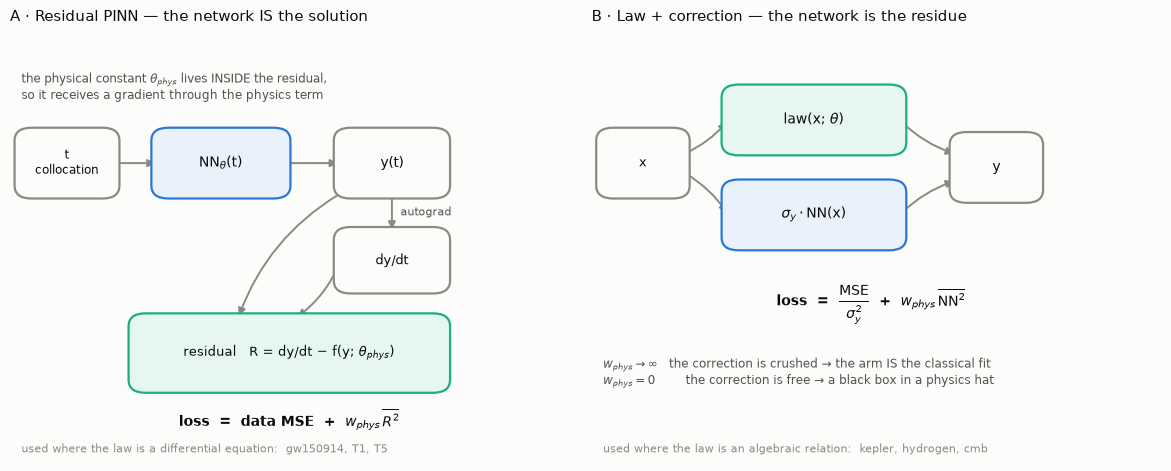

In [2]:
P.fig_pinn_anatomy(); plt.show()

## The answer, in one figure

The scorecard across the four real-data tracks: **most protocol
questions do not separate the arms at all**, and the `pinn` arm wins one cell
in twelve.

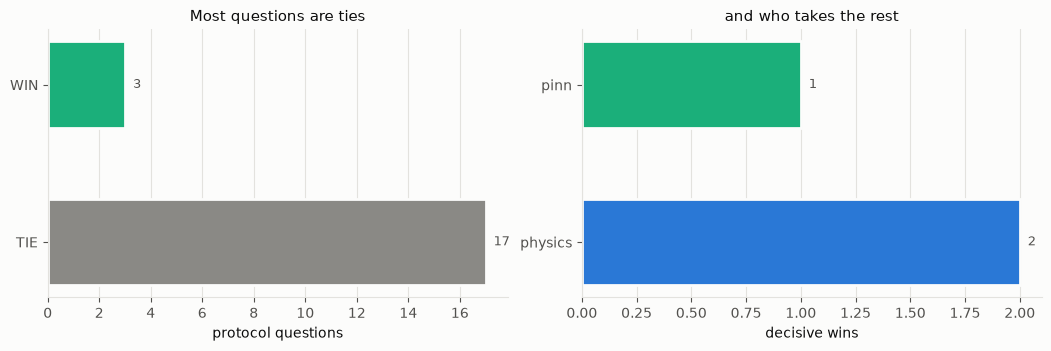

In [3]:
from physprior.reporting import conclusions as C
frame = C.verdict_frame("all")
counts = frame.verdict.str.split(" ").str[0].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.4))
ax = axes[0]
ax.barh(list(counts.index), list(counts.values),
        color=[{"WIN": P.ARM_COLOR["pinn"]}.get(k, P.INK_MUTED) for k in counts.index],
        edgecolor=P.SURFACE, linewidth=2, height=0.55)
for k, v in counts.items():
    ax.annotate(f"  {v}", xy=(v, k), va="center", fontsize=9, color=P.INK_2)
ax.set_xlabel("protocol questions"); ax.grid(axis="y", visible=False)
ax.set_title("Most questions are ties")

ax = axes[1]
wins = frame[frame.verdict.str.startswith("WIN")].winner.value_counts()
ax.barh(list(wins.index), list(wins.values),
        color=[P.ARM_COLOR.get(a, P.INK_MUTED) for a in wins.index],
        edgecolor=P.SURFACE, linewidth=2, height=0.55)
for k, v in wins.items():
    ax.annotate(f"  {v}", xy=(v, k), va="center", fontsize=9, color=P.INK_2)
ax.set_xlabel("decisive wins"); ax.grid(axis="y", visible=False)
ax.set_title("and who takes the rest")
plt.show()

That is a real result, and it is not the one the field usually reports. It is
also **not** evidence that physics-informed learning does not work — it is
evidence that these four tracks are mostly the wrong test.

## Three regimes, and only one of them is a fair test

| regime | example here | who wins |
|---|---|---|
| the law is **exact** | `gravity/kepler` | `physics` — the prior has nothing to add |
| the missing piece is **degenerate** with the law | `quantum/cmb` | nobody — the constant is not identifiable |
| the missing piece is **distinguishable** | [T7](tutorials/T7_when_the_prior_wins.ipynb) | **`pinn`, by an order of magnitude** |

The third regime is the normal condition of applied physics, and it was
missing from the real tracks. [T7](tutorials/T7_when_the_prior_wins.ipynb)
builds it as a controlled experiment:

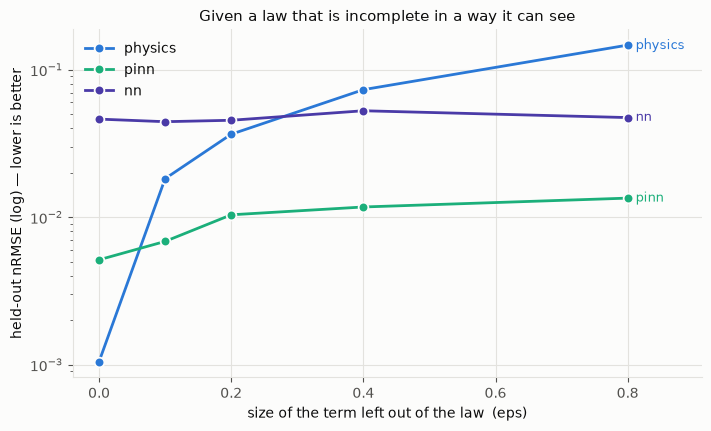

In [4]:
import pandas as pd
eps = pd.read_csv("results/neglected_eps.csv")
P.fig_neglected_sweep(eps, "eps", "size of the term left out of the law  (eps)",
                      "Given a law that is incomplete in a way it can see")
plt.show()

## The constants this project recovered from real data

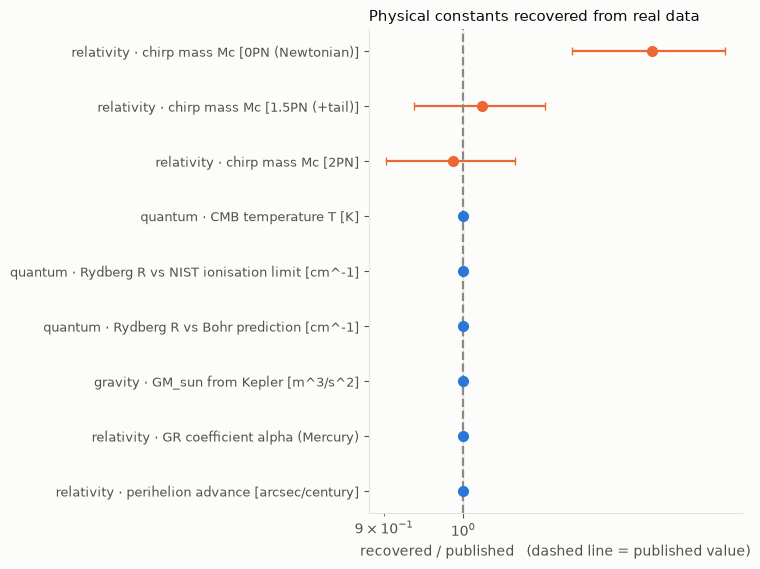

In [5]:
h = json.load(open(RESULTS / "headline.json"))
P.fig_parameter_recovery(h["parameter_recovery"]); plt.show()

## Extrapolation, across the benchmark tracks

Each arm is fitted on the *low* part of its range and asked about the *high*
part. This is where a prior either pays or does not.

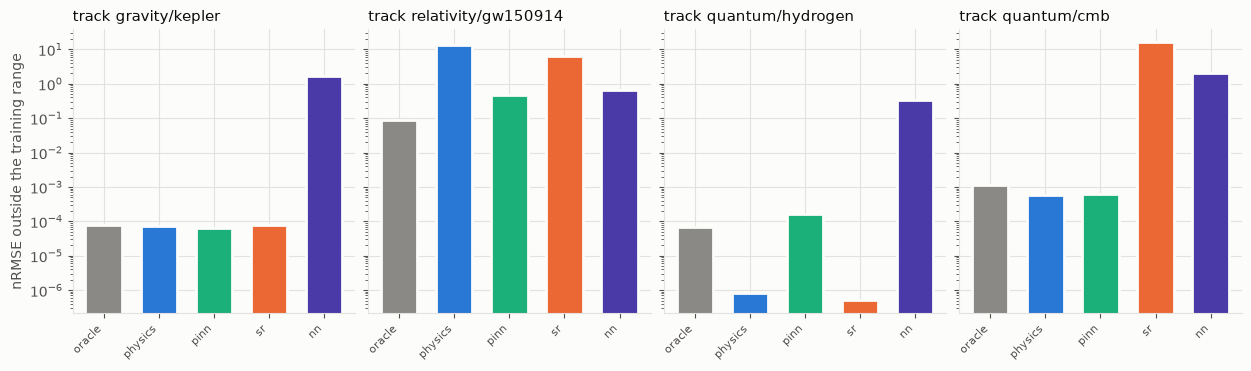

In [6]:
P.fig_cross_track_extrapolation(h["extrapolation_summary"]); plt.show()

## The findings

1. **Inside the training range, with enough clean data, a tuned black box is
   competitive.** Physics buys little there, and claims to the contrary
   usually compare against an untuned baseline.
2. **Outside it the gap is orders of magnitude — but the mechanism is
   identifiability, not the mere presence of a law.** On `quantum/cmb`
   out-of-band error falls ~56× as the fitted band reaches the Rayleigh–Jeans
   regime *while in-band error gets worse*.
3. **Only the physics arms return something a physicist can argue with** —
   QED in hydrogen, the post-Newtonian expansion in GW150914, and a
   truncation error masquerading as a 56σ refutation of general relativity.
4. **The network eats the physics if you let it.** At `w_phys = 0` the
   recovered `GM_sun` is 19.5% wrong while held-out error barely moves.
5. **A pipeline you have not injected into has no error budget.**

### Where to go next

| | |
|---|---|
| [tutorials/](tutorials/README.md) | a step-by-step PINN course, T1 → T7 |
| [01_gravity](01_gravity.ipynb) · [02_relativity](02_relativity.ipynb) · [03_quantum](03_quantum.ipynb) | the three problems in full |
| [T7](tutorials/T7_when_the_prior_wins.ipynb) | the regime where the prior wins, and why the others do not |

---

## Conclusion

Everything below is rendered from `results/` at execution time by
`physprior.reporting.conclusions` — the verdicts, the margins and the prose.
A gap smaller than the seed-to-seed spread on the reporting seeds
(11 / 23 / 42) is reported as a **tie**, not rounded into a win.

In [7]:
from physprior.reporting import conclusions as C
verdicts = C.verdict_frame('all')
display(verdicts)

,track,question,winner,runner-up,margin,seed spread,verdict
0,gravity/kepler,interpolation,physics,sr,1.09x,3.7e-05,TIE (within seed spread)
1,gravity/kepler,data efficiency,physics,pinn,3.89x,0.0012,TIE (within seed spread)
2,gravity/kepler,noise,physics,pinn,1x,0.094,TIE (within seed spread)
3,gravity/kepler,extrapolation,pinn,physics,1.27x,1.7e-05,TIE (within seed spread)
4,gravity/kepler,parameter recovery (GM),physics,pinn,1x,0.00071,TIE (within seed spread)
5,relativity/gw150914,interpolation,physics,pinn,1.07x,0.14,TIE (within seed spread)
6,relativity/gw150914,data efficiency,pinn,nn,1.22x,0.16,TIE (within seed spread)
7,relativity/gw150914,noise,physics,pinn,1.27x,0.3,TIE (within seed spread)
8,relativity/gw150914,extrapolation,pinn,nn,1.33x,0.097,WIN
9,relativity/gw150914,parameter recovery (Mc),physics,pinn,1.12x,5.2,TIE (within seed spread)


In [8]:
from IPython.display import Markdown
display(Markdown(C.conclusion_markdown('all')))

Across 20 protocol questions on 4 track(s), **3 produced a decisive answer** and 17 were inside the seed-to-seed spread and are reported as ties rather than rounded into wins. **`physics` takes 2 of the decisive question(s)** (`pinn` 1). The largest single gap is on **quantum/hydrogen / data efficiency**, where `physics` beats `sr` by **9.19x**. The `pinn` arm — the one this project is built around — wins **1**, loses **2** and ties **17** of these, which is the number to read before any claim about what a physics prior buys. An arm beats the **oracle** out of range (`pinn` on gravity/kepler by 1.28x; `physics` on quantum/hydrogen by 83.7x; `sr` on quantum/hydrogen by 102x; `physics` on quantum/cmb by 2.01x; `pinn` on quantum/cmb by 1.75x): the oracle carries the *published* constant, so this is a claim about that constant, and the track's `meta.json` records the explanation.

In [9]:
lines = ["- " + line for line in C.what_would_change_this('all')]
display(Markdown("**What would change this conclusion**\n\n" + "\n".join(lines)))

**What would change this conclusion**

- `physics` wins 2 question(s) (hydrogen data efficiency; hydrogen parameter recovery (R)): it assumes the published law is right. A track where the law is incomplete — a truncated expansion, a neglected term — removes that advantage, which is exactly what the `pinn` arm exists to test.
- `pinn` wins 1 question(s) (gw150914 extrapolation): the neural correction pays only when the law has something left over for it to absorb. Fitting the same track with the complete law would remove the residual it is exploiting and the win with it.
- 17 question(s) are ties: more seeds, or a lower-variance fit (ensembling, early stopping), would decide them either way.
- The 9.19x gap on quantum/hydrogen / data efficiency rests on three seeds with a spread of 5.8e-06; it would be overturned by a seed set on which `sr` closes to within that spread, which is why the margin and the spread are printed side by side above.
- The oracle being beaten would be overturned by a revised published constant: the oracle is only as good as the literature value it carries.